# ENSF 444 Final Project - Airbnb Price Prediction in Calgary
Amielle El Makhzoumi & Fatma Alzubaidi - Group 27

The goal of our project is to predict the nightly price of an Airbnb listing in Calgary using listing characteristics like room type, neighbourhood, number of bedrooms, and host attributes. We compared three machine learning models (linear regression, random forest, and gradient boosting) to determine which produces the most accurate price predictions for Calgary hosts.

In [253]:
# Importing all required modules
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Loading the Dataset

The airbnb_calgary.csv dataset is in the same folder as this jupyter notebook file.

In [254]:
df = pd.read_csv("airbnb_calgary.csv") # Reading the dataset
df.head() # Displaying the first few rows of the dataset

,Country,Location,Airbnb_ListingID,Scrape_Date,Lat,Lng,City,LocalizedCity,LocalizedNeighbourhood_Source,LocalizedNeighbourhood_ML,...,BasicNightPrice,Taxes,BasicNightPriceString_USD,BasicNightPrice_USD,Taxes_USD,isOverpricedPerBeds_Calc,isOverpricedPerGuest_Calc,Amenities_SelfCheckIn,HostLanguages_Verbose,RecordInserted
0,Canada,Calgary,937715569409099752,2025-10-29,51.04095,-114.05496,Calgary,Calgary,Beltline,Beltline,...,NaN,NaN,NaN,NaN,NaN,0,0,True,['English'],2025-10-29 18:17:30
1,Canada,Calgary,32673090,2025-10-29,51.04100,-114.07015,Calgary,Calgary,Beltline,Beltline,...,NaN,NaN,NaN,NaN,NaN,0,0,False,[],2025-10-29 18:17:36
2,Canada,Calgary,21531279,2025-10-29,51.04938,-114.08603,Calgary,Calgary,Downtown Calgary,Downtown Calgary,...,NaN,NaN,NaN,NaN,NaN,0,0,True,['English'],2025-10-29 18:17:58
3,Canada,Calgary,43868185,2025-10-29,51.15801,-113.96024,Calgary,Calgary,Skyview Ranch,Skyview Ranch,...,414.00,181.21,5 nights x $297.04,297.0,130.0,1,0,True,['English' 'French' 'Tagalog'],2025-10-29 18:20:00
4,Canada,Calgary,1435646668154816977,2025-10-29,50.97939,-114.06274,Calgary,Calgary,Acadia,NaN,...,246.73,104.55,5 nights x $177.50,177.0,75.0,0,0,True,[],2025-10-29 18:21:58


### Exploratory Data Analysis
Before preprocessing, we explored the dataset to understand its structure, distributions, and relationships between features and our target variable.

In [255]:
# Basic shape and info
print(f"Shape: {df.shape}")
print(f"\nMissing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0]) # Displaying columns with missing values

Shape: (5351, 44)

Missing values per column:
LocalizedNeighbourhood_Source     850
LocalizedNeighbourhood_ML        1225
LocalizedNeighbourhood            749
Bathrooms                           3
Bedrooms                            3
RoomType_Clean                      8
ReviewScore                       902
StarRating                        902
BasicNightPrice_CheckIn           628
BasicNightPrice_CheckOut          628
BasicNightPrice                   628
Taxes                             628
BasicNightPriceString_USD         628
BasicNightPrice_USD               628
Taxes_USD                         628
Amenities_SelfCheckIn               2
dtype: int64


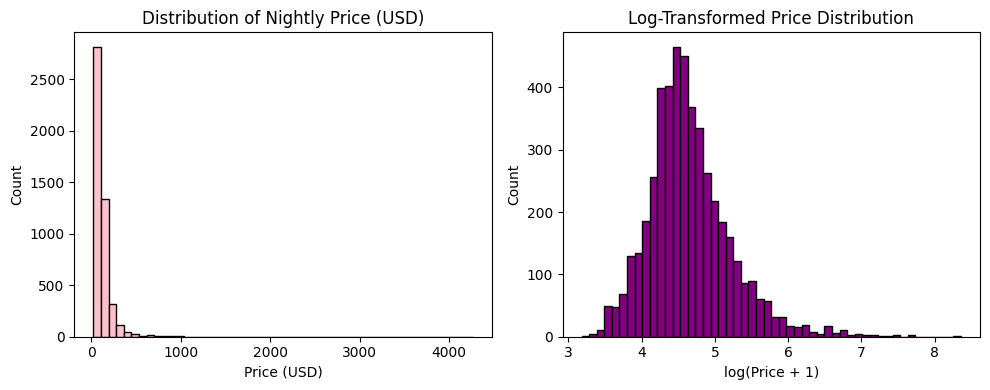

In [256]:
# Distribution of our target variable
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(df['BasicNightPrice_USD'].dropna(), bins=50, color='pink', edgecolor='black')
plt.title('Distribution of Nightly Price (USD)')
plt.xlabel('Price (USD)')
plt.ylabel('Count')

# Log-transforming the price to reduce skewness
plt.subplot(1, 2, 2)
plt.hist(np.log1p(df['BasicNightPrice_USD'].dropna()), bins=50, color='purple', edgecolor='black')
plt.title('Log-Transformed Price Distribution')
plt.xlabel('log(Price + 1)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

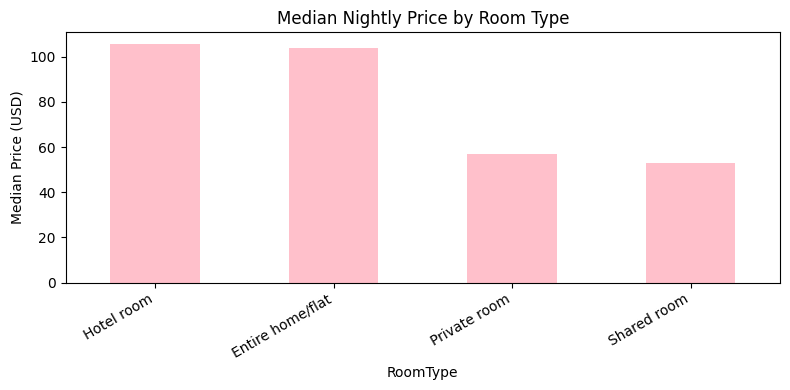

In [257]:
# Median price by room type
room_avg = df.groupby('RoomType')['BasicNightPrice_USD'].median().sort_values(ascending=False)
room_avg.plot(kind='bar', color='pink', figsize=(8, 4))
plt.title('Median Nightly Price by Room Type')
plt.ylabel('Median Price (USD)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

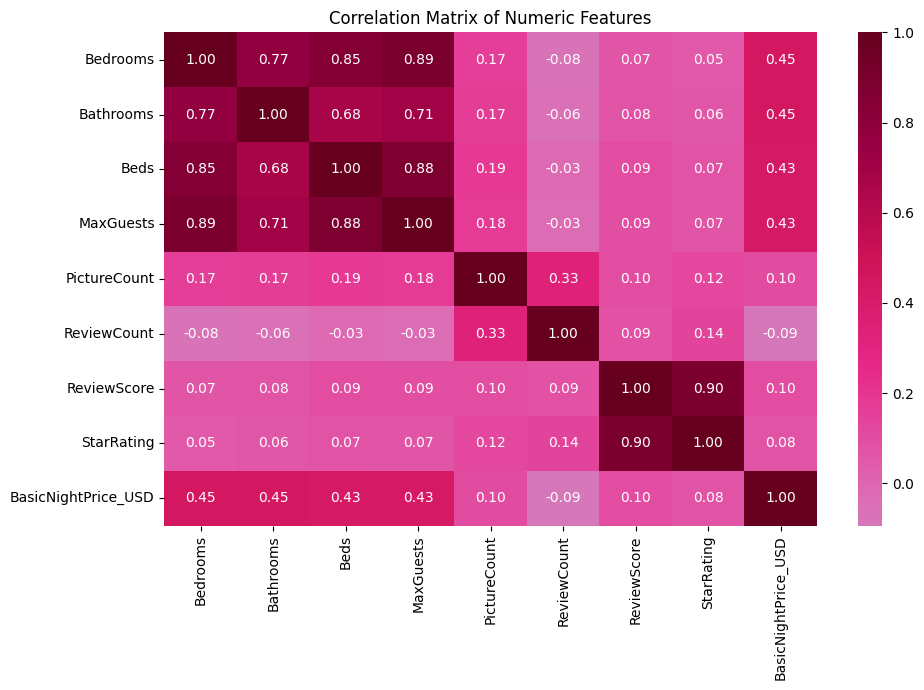

In [258]:
# Correlation heatmap of numeric features with price
numeric_cols = ['Bedrooms', 'Bathrooms', 'Beds', 'MaxGuests', 'PictureCount','ReviewCount', 'ReviewScore', 'StarRating', 'BasicNightPrice_USD']
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='PuRd', center=0)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

### Data Cleaning

We started by dropping columns that are identifiers or redundant (like listing ID, host name, dates, duplicate price columns). We filled missing numeric values with the median for that column and missing categorical values with "Unknown". We then removed price outliers using IQR filtering becuase extreme listings (like $4,000/night) would distort the model's learning. Finally, we one-hot encoded categorical columns so the models can process them.

In [259]:
# Drop irrelevant identifiers, date columns, leakage columns, and duplicates
drops = [
    'Airbnb_ListingID', 'Host_ID', 'Host_FirstName', 'ListingTitle', # Don't generalize
    'Scrape_Date', 'RecordInserted', 'Country', 'City', 'LocalizedCity', # Create too many dummies
    'Location', 'HostLanguages_Verbose', 
    'BasicNightPrice_CheckIn', 'BasicNightPrice_CheckOut', # Leakage columns with direct price info
    'BasicNightPrice', 'Taxes', 'BasicNightPriceString_USD', 'Taxes_USD', # More leakage columns
    'isOverpricedPerBeds_Calc', 'isOverpricedPerGuest_Calc', # More leakage columns
    'LocalizedNeighbourhood_Source', 'LocalizedNeighbourhood_ML', # Too many unique values to encode effectively
    'Currency', 'isLimitedAirbnbData', 'isSuperhost', # Too many unique values to encode effectively
    'RoomType_Clean', 'SpaceType_Clean' # Duplicates of RoomType and SpaceType
]
df = df.drop(columns=drops, errors='ignore')

# Fill missing numeric values with median for that column & categorical with 'Unknown'
df = df.fillna(df.median(numeric_only=True))
df = df.fillna('Unknown')

# Remove price outliers using IQR since extreme listings would skew model training
Q1 = df['BasicNightPrice_USD'].quantile(0.25)
Q3 = df['BasicNightPrice_USD'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['BasicNightPrice_USD'] >= Q1 - 1.5*IQR) & (df['BasicNightPrice_USD'] <= Q3 + 1.5*IQR)] # Removing outliers based on IQR

print(f"Remaining rows after removing outliers: {len(df)}")
df.head()

Remaining rows after removing outliers: 4861


,Lat,Lng,LocalizedNeighbourhood,Bathrooms,Bedrooms,Beds,MaxGuests,Host_isSuperhost,isNewListing,RoomType,SpaceType,isHomeOrServicedApartment,PictureCount,ReviewCount,ReviewScore,StarRating,BasicNightPrice_USD,Amenities_SelfCheckIn
0,51.04095,-114.05496,Beltline,2.0,2.0,2.0,4,False,False,Entire home/flat,Entire apartment,1,37,106,4.78,5.0,96.0,True
1,51.04100,-114.07015,Beltline,1.0,1.0,1.0,3,False,False,Entire home/flat,Entire apartment,1,17,107,4.92,5.0,96.0,False
2,51.04938,-114.08603,Downtown Calgary,1.0,1.0,2.0,2,False,False,Entire home/flat,Entire apartment,1,18,203,4.87,5.0,96.0,True
4,50.97939,-114.06274,Acadia,1.5,1.0,1.0,2,False,False,Entire home/flat,Entire apartment,1,0,7,5.00,5.0,177.0,True
5,50.86792,-113.95509,Seton,1.0,2.0,1.0,4,True,False,Entire home/flat,Entire apartment,1,0,15,4.93,5.0,84.0,True


### Feature Engineering & Encoding

We one-hot encoded all the categorical features left so they can be used by our models. We used drop_first=True to avoid multicollinearity.

In [260]:
df = pd.get_dummies(df, drop_first=True) # One-hot encoding categorical variables

In [261]:
X = df.drop("BasicNightPrice_USD", axis=1) # Features
y = df["BasicNightPrice_USD"] # Target

In [262]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 80-20 train-test split

In [263]:
scaler = StandardScaler() # Scaling features for better model performance, especially for linear regression

X_train_scaled = scaler.fit_transform(X_train) # Fit the scaler on training data and transform it
X_test_scaled = scaler.transform(X_test) # Transform test data using the same scaler fitted on training data

### Training the models

Linear Regression is our baseline. It assumes a linear relationship between features and price. It may not capture complex patterns but it gives us a base performance to compare against. 

Random Forest Regressor handles non-linearity and feature interactions well. It is naturally robust to outliers and does not require scaling.

Gradient Boosting Regressor builds trees sequentially and has each correcting the errors of the previous. It usually achieves high accuracy on structured tabular data like this dataset.

We used scaled features (X_train_scaled) for Linear Regression and unscaled data (X_train) for the two tree-based models since they are scale-invariant.

In [264]:
# Linear Regression - our baseline model
lr = LinearRegression()
lr.fit(X_train_scaled, y_train) # Train the linear regression model on the scaled training data

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [265]:
# Random Forest
rf = RandomForestRegressor(n_estimators=200, # n_estimators=200 for stability
                           max_depth=15, # max_depth=15 for complexity, 
                           min_samples_leaf=3, # min_samples_leaf=3 to reduce overfitting
                           random_state=42)
rf.fit(X_train, y_train) # Train the random forest model on the unscaled training data 

,n_estimators,200
,criterion,'squared_error'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [266]:
# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=300, # n_estimators=300 for more trees
                               learning_rate=0.05, # learning_rate=0.05 for slower learning and better generalization
                               max_depth=5, # max_depth=5 to keep individual trees shallow
                               min_samples_leaf=5, # min_samples_leaf=5 to reduce overfitting
                               random_state=42) 
gb.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.05
,n_estimators,300
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_depth,5
,min_impurity_decrease,0.0
,init,None


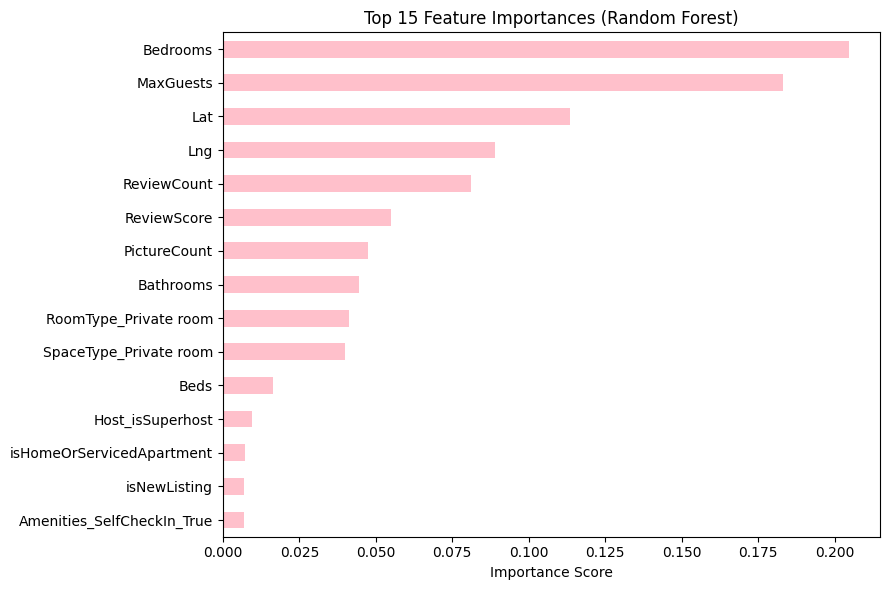

In [267]:
# Feature importance from Random Forest (top 15 features)
feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = feat_importances.nlargest(15)

top_features.sort_values().plot(kind='barh', figsize=(9, 6), color='pink')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

### Model Comparisons

We evaluated each model using MAE, RMSE, and R2 on the test set. Lower MAE and RMSE indicate better prediction accuracy, and a higher R2 indicates more variance explained.

In [268]:
# Evaluation function to calculate MAE, RMSE, and R2
def evaluate(model, X_test, y_test):
    preds = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    return mae, rmse, r2

In [269]:
lr_results = evaluate(lr, X_test_scaled, y_test) # Evaluating linear regression on scaled test data
rf_results = evaluate(rf, X_test, y_test) # Evaluating random forest on unscaled test data
gb_results = evaluate(gb, X_test, y_test) # Evaluating gradient boosting on unscaled test data

In [270]:
results = pd.DataFrame({ 
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "MAE": [lr_results[0], rf_results[0], gb_results[0]],
    "RMSE": [lr_results[1], rf_results[1], gb_results[1]],
    "R2": [lr_results[2], rf_results[2], gb_results[2]]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,19.152955,25.083274,0.525826
1,Random Forest,17.674672,23.418645,0.586674
2,Gradient Boosting,17.653314,23.258560,0.592305


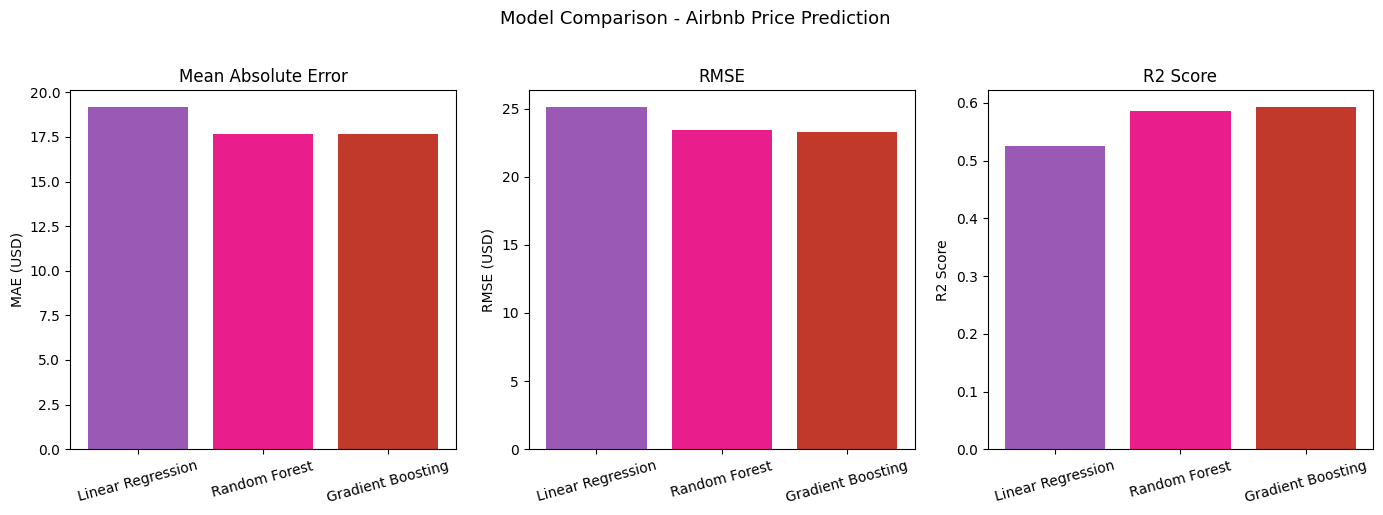

In [271]:
# Bar charts for all three metrics
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

colors = ['#9b59b6', '#e91e8c', '#c0392b']

axes[0].bar(results['Model'], results['MAE'], color=colors)
axes[0].set_title('Mean Absolute Error')
axes[0].set_ylabel('MAE (USD)')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(results['Model'], results['RMSE'], color=colors)
axes[1].set_title('RMSE')
axes[1].set_ylabel('RMSE (USD)')
axes[1].tick_params(axis='x', rotation=15)

axes[2].bar(results['Model'], results['R2'], color=colors)
axes[2].set_title('R2 Score')
axes[2].set_ylabel('R2 Score')
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Model Comparison - Airbnb Price Prediction', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

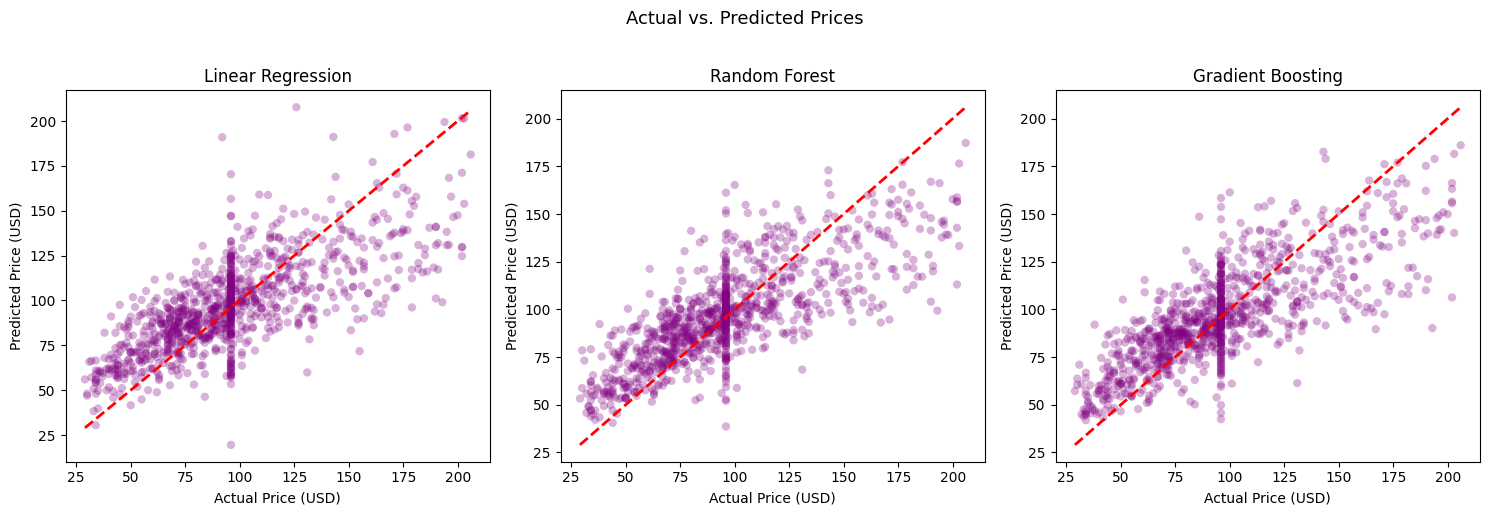

In [272]:
# Actual vs Predicted scatter plots for each model
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models_info = [
    ('Linear Regression', lr, X_test_scaled), 
    ('Random Forest', rf, X_test),
    ('Gradient Boosting', gb, X_test)
]

# Loop through each model and create a scatter plot of actual vs predicted prices
for ax, (name, model, X_input) in zip(axes, models_info):
    preds = model.predict(X_input)
    ax.scatter(y_test, preds, alpha=0.3, color='purple', edgecolors='none')
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax.set_xlabel('Actual Price (USD)')
    ax.set_ylabel('Predicted Price (USD)')
    ax.set_title(name)

plt.suptitle('Actual vs. Predicted Prices', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Results & Interpretation

After comparing our three models, Gradient Boosting achieved the best overall performance because it had an R2 of 0.5923, MAE of $17.65, and RMSE of $23.26. Random Forest was a very close second with R2 = 0.5867 and MAE = $17.67, while Linear Regression was noticeably behind with R2 = 0.5258 and MAE = $19.15.

The gap between Linear Regression and the two ensemble models confirms the expectation we had from our proposal. We knew that Airbnb pricing is not a linear problem. Features like neighbourhood, room type, and number of bedrooms influence each other in complex ways that a linear model can not capture. This is reflected directly through the 7% improvement in R2 from Linear Regression to Gradient Boosting.

An R2 of 0.59 means that our best model explains approximately 59% of the variance in nightly prices, with a mean absolute error of about $17.65 USD. Since prices in our dataset range from $23 to $206 after removing outliers (a spread of $183), being off by about $18 on average is competitive. Our dataset also did not include listing descriptions or seasonal demand data which would realistically influence a host's price but are not captured here. This model gives a data-driven price estimate that is much better than guessing for Calgary hosts.

The feature importance plot from Random Forest shows that bedrooms, maxGuests, lat, lng, and reviewCount are the most influential predictors. This makes sense logically since larger listings in desirable locations with more reviews are listed at higher prices.